# 03 · Pandas — Data Analysis & Manipulation

**Difficulty:** Beginner-Intermediate | **Time:** ~3 hours

Pandas is the **Excel of Python** — but infinitely more powerful. You will use it in every data science project.

## Table of Contents
1. Series & DataFrame Basics
2. Loading Data (CSV, Excel, JSON)
3. Exploring Data (EDA)
4. Selecting & Filtering
5. Handling Missing Values
6. GroupBy & Aggregations
7. Merging & Joining
8. Real-world Project: Sales Analysis

## 1. Series & DataFrame Basics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Series — 1D labeled array
temps = pd.Series([35.1, 36.4, 34.8, 37.2, 38.0],
                  index=["Mon","Tue","Wed","Thu","Fri"],
                  name="Temperature (°C)")
print(temps)
print(f"\nMean: {temps.mean():.1f}°C  |  Max: {temps.max()}°C on {temps.idxmax()}")

Mon    35.1
Tue    36.4
Wed    34.8
Thu    37.2
Fri    38.0
Name: Temperature (°C), dtype: float64

Mean: 36.3°C  |  Max: 38.0°C on Fri


In [2]:
# DataFrame — 2D table (the workhorse)
data = {
    "Name"  : ["Alice","Bob","Carol","David","Eve","Frank"],
    "Age"   : [25, 30, 22, 35, 28, 42],
    "City"  : ["Mumbai","Delhi","Bangalore","Mumbai","Chennai","Delhi"],
    "Salary": [55000, 72000, 48000, 95000, 61000, 88000],
    "Exp_Years": [2, 5, 1, 10, 3, 15]
}
df = pd.DataFrame(data)
print(df)
print(f"\nShape: {df.shape}  |  Columns: {list(df.columns)}")

    Name  Age       City  Salary  Exp_Years
0  Alice   25     Mumbai   55000          2
1    Bob   30      Delhi   72000          5
2  Carol   22  Bangalore   48000          1
3  David   35     Mumbai   95000         10
4    Eve   28    Chennai   61000          3
5  Frank   42      Delhi   88000         15

Shape: (6, 5)  |  Columns: ['Name', 'Age', 'City', 'Salary', 'Exp_Years']


## 2. Loading Real Data

In [3]:
import io

# Simulating a real CSV dataset: Titanic-style passenger data
csv_data = """PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked\n1,0,3,Braund Mr. Owen,male,22,7.25,S\n2,1,1,Cumings Mrs. John,female,38,71.28,C\n3,1,3,Heikkinen Miss. Laina,female,26,7.92,S\n4,1,1,Futrelle Mrs. Jacques,female,35,53.10,S\n5,0,3,Allen Mr. William,male,35,8.05,S\n6,0,3,Moran Mr. James,male,,8.46,Q\n7,0,1,McCarthy Mr. Timothy,male,54,51.86,S\n8,0,3,Palsson Master Gosta,male,2,21.07,S\n9,1,3,Johnson Mrs. Oscar,female,27,11.13,S\n10,1,2,Nasser Mrs. Nicholas,female,14,30.07,C\n11,1,3,Sandstrom Miss Marguerite,female,4,16.70,S\n12,1,1,Bonnell Miss Elizabeth,female,58,26.55,S\n"""

titanic = pd.read_csv(io.StringIO(csv_data))
print("Shape:", titanic.shape)
print(titanic)

Shape: (12, 8)
    PassengerId  Survived  Pclass                       Name     Sex   Age  \
0             1         0       3            Braund Mr. Owen    male  22.0   
1             2         1       1          Cumings Mrs. John  female  38.0   
2             3         1       3      Heikkinen Miss. Laina  female  26.0   
3             4         1       1      Futrelle Mrs. Jacques  female  35.0   
4             5         0       3          Allen Mr. William    male  35.0   
5             6         0       3            Moran Mr. James    male   NaN   
6             7         0       1       McCarthy Mr. Timothy    male  54.0   
7             8         0       3       Palsson Master Gosta    male   2.0   
8             9         1       3         Johnson Mrs. Oscar  female  27.0   
9            10         1       2       Nasser Mrs. Nicholas  female  14.0   
10           11         1       3  Sandstrom Miss Marguerite  female   4.0   
11           12         1       1     Bonnell Mis

## 3. Exploring Data (EDA)

In [4]:
# The first thing you do with ANY new dataset
print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== STATISTICS ===")
print(df.describe())

=== SHAPE ===
(6, 5)

=== DATA TYPES ===
Name           str
Age          int64
City           str
Salary       int64
Exp_Years    int64
dtype: object

=== STATISTICS ===
             Age        Salary  Exp_Years
count   6.000000      6.000000   6.000000
mean   30.333333  69833.333333   6.000000
std     7.229569  18669.940189   5.440588
min    22.000000  48000.000000   1.000000
25%    25.750000  56500.000000   2.250000
50%    29.000000  66500.000000   4.000000
75%    33.750000  84000.000000   8.750000
max    42.000000  95000.000000  15.000000


In [5]:
print("=== MISSING VALUES ===")
print(titanic.isnull().sum())
print(f"\nMissing %:")
print((titanic.isnull().sum() / len(titanic) * 100).round(1))

=== MISSING VALUES ===
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            1
Fare           0
Embarked       0
dtype: int64

Missing %:
PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            8.3
Fare           0.0
Embarked       0.0
dtype: float64


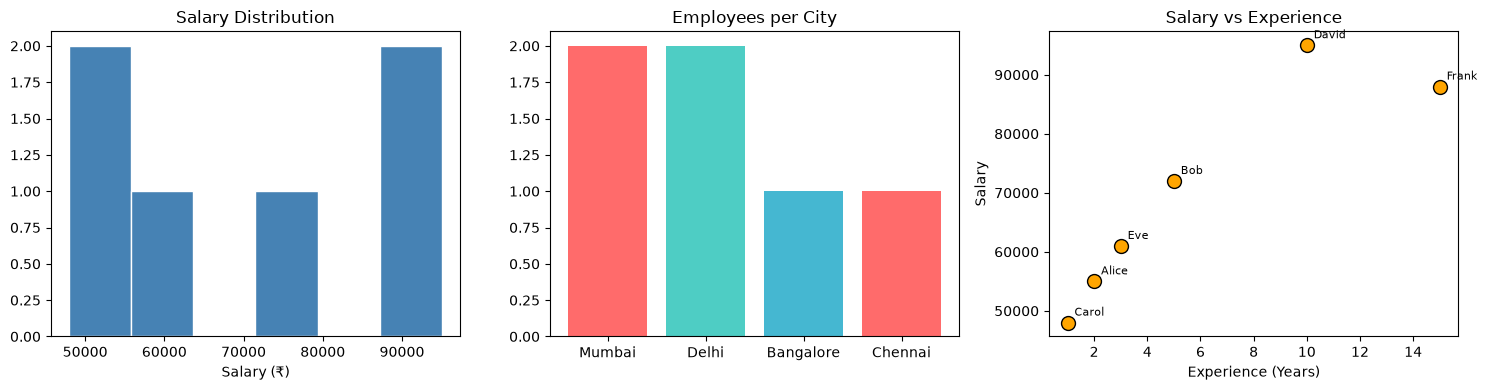

In [6]:
# Visual overview of our employee DataFrame
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Salary distribution
axes[0].hist(df['Salary'], bins=6, color='steelblue', edgecolor='white')
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Salary (₹)")

# Employees per city
city_counts = df['City'].value_counts()
axes[1].bar(city_counts.index, city_counts.values, color=['#FF6B6B','#4ECDC4','#45B7D1'])
axes[1].set_title("Employees per City")

# Salary vs Experience
axes[2].scatter(df['Exp_Years'], df['Salary'], s=100, c='orange', edgecolors='black')
for _, row in df.iterrows():
    axes[2].annotate(row['Name'], (row['Exp_Years'], row['Salary']), 
                     textcoords="offset points", xytext=(5,5), fontsize=8)
axes[2].set_xlabel("Experience (Years)")
axes[2].set_ylabel("Salary")
axes[2].set_title("Salary vs Experience")

plt.tight_layout()
plt.savefig("/tmp/pandas_eda.png", dpi=100)
plt.show()

## 4. Selecting & Filtering

In [7]:
# Column selection
print("Single column:\n", df['Name'].values)
print("\nMultiple columns:")
print(df[['Name','Salary']])

Single column:
 <StringArray>
['Alice', 'Bob', 'Carol', 'David', 'Eve', 'Frank']
Length: 6, dtype: str

Multiple columns:
    Name  Salary
0  Alice   55000
1    Bob   72000
2  Carol   48000
3  David   95000
4    Eve   61000
5  Frank   88000


In [8]:
# Row filtering with conditions
print("Salary > 60000:")
print(df[df['Salary'] > 60000])

print("\nFrom Mumbai with Salary > 50000:")
print(df[(df['City'] == 'Mumbai') & (df['Salary'] > 50000)])

print("\nTop earner:")
print(df.loc[df['Salary'].idxmax()])

Salary > 60000:
    Name  Age     City  Salary  Exp_Years
1    Bob   30    Delhi   72000          5
3  David   35   Mumbai   95000         10
4    Eve   28  Chennai   61000          3
5  Frank   42    Delhi   88000         15

From Mumbai with Salary > 50000:
    Name  Age    City  Salary  Exp_Years
0  Alice   25  Mumbai   55000          2
3  David   35  Mumbai   95000         10

Top earner:
Name          David
Age              35
City         Mumbai
Salary        95000
Exp_Years        10
Name: 3, dtype: object


In [9]:
# .loc vs .iloc
print("Row by label (.loc):")
print(df.loc[0, ['Name','Salary']])

print("\nRow by position (.iloc):")
print(df.iloc[0:3, 0:3])  # first 3 rows, first 3 cols

Row by label (.loc):
Name      Alice
Salary    55000
Name: 0, dtype: object

Row by position (.iloc):
    Name  Age       City
0  Alice   25     Mumbai
1    Bob   30      Delhi
2  Carol   22  Bangalore


## 5. Handling Missing Values

In [10]:
# Create a dataset with intentional missing values
np.random.seed(42)
n = 20
df_missing = pd.DataFrame({
    'Age'   : np.random.randint(20, 60, n),
    'Income': np.random.randint(30000, 120000, n),
    'Score' : np.random.uniform(0, 100, n).round(1)
})
# Introduce missing values
df_missing.loc[[2, 5, 11], 'Age']    = np.nan
df_missing.loc[[0, 7, 14, 18], 'Income'] = np.nan
df_missing.loc[[3, 9], 'Score']      = np.nan

print("Missing values:")
print(df_missing.isnull().sum())

# Strategy 1: Drop rows
df_drop = df_missing.dropna()
print(f"\nAfter dropna: {len(df_drop)} rows (lost {len(df_missing)-len(df_drop)})")

# Strategy 2: Fill with mean (for numeric)
df_filled = df_missing.copy()
df_filled['Age']    = df_filled['Age'].fillna(df_filled['Age'].median())
df_filled['Income'] = df_filled['Income'].fillna(df_filled['Income'].mean())
df_filled['Score']  = df_filled['Score'].fillna(df_filled['Score'].mean())
print(f"\nAfter fillna: {df_filled.isnull().sum().sum()} missing values")

Missing values:
Age       3
Income    4
Score     2
dtype: int64

After dropna: 11 rows (lost 9)

After fillna: 0 missing values


## 6. GroupBy & Aggregations

In [11]:
# GroupBy = SQL GROUP BY — aggregate by category
print("Average salary by city:")
city_stats = df.groupby('City')['Salary'].agg(['mean','min','max','count'])
print(city_stats.round(0))

print("\nMultiple column aggregation:")
print(df.groupby('City').agg({'Salary':'mean', 'Age':'mean', 'Exp_Years':'sum'}).round(1))

Average salary by city:
              mean    min    max  count
City                                   
Bangalore  48000.0  48000  48000      1
Chennai    61000.0  61000  61000      1
Delhi      80000.0  72000  88000      2
Mumbai     75000.0  55000  95000      2

Multiple column aggregation:
            Salary   Age  Exp_Years
City                               
Bangalore  48000.0  22.0          1
Chennai    61000.0  28.0          3
Delhi      80000.0  36.0         20
Mumbai     75000.0  30.0         12


Sales Pivot Table:
Region  North  South
Month               
Feb      8645   9062
Jan      9401   5349
Mar      6801  10641


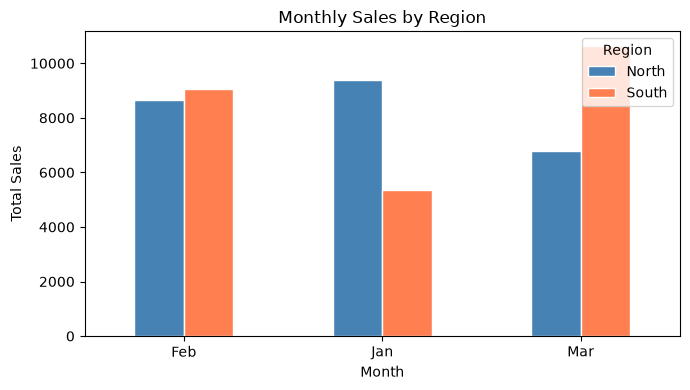

In [12]:
# Pivot table — like Excel pivot tables
# Real-world: sales data
np.random.seed(0)
sales = pd.DataFrame({
    'Month'  : ['Jan','Jan','Feb','Feb','Mar','Mar'] * 3,
    'Region' : ['North','South'] * 9,
    'Product': ['A','A','A','B','B','B','C','C','C','A','B','C','A','B','C','A','B','C'],
    'Sales'  : np.random.randint(500, 5000, 18)
})

pivot = pd.pivot_table(sales, values='Sales', index='Month', columns='Region', aggfunc='sum')
print("Sales Pivot Table:")
print(pivot)

fig, ax = plt.subplots(figsize=(7, 4))
pivot.plot(kind='bar', ax=ax, color=['steelblue','coral'], edgecolor='white')
ax.set_title("Monthly Sales by Region")
ax.set_ylabel("Total Sales")
ax.legend(title='Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/tmp/pivot_sales.png", dpi=100)
plt.show()

## 7. Merging & Joining

In [13]:
# Like SQL JOINs
employees = pd.DataFrame({
    'EmpID': [1, 2, 3, 4, 5],
    'Name' : ['Alice','Bob','Carol','David','Eve'],
    'DeptID': [10, 20, 10, 30, 20]
})

departments = pd.DataFrame({
    'DeptID'  : [10, 20, 30],
    'DeptName': ['Engineering','Marketing','HR']
})

# Inner join
merged = pd.merge(employees, departments, on='DeptID', how='inner')
print("Inner Join (all employees with their dept):")
print(merged)

# Left join (keep all employees even if dept not found)
departments_partial = departments.iloc[:2]  # only 2 depts
left_merged = pd.merge(employees, departments_partial, on='DeptID', how='left')
print("\nLeft Join (some depts missing → NaN):")
print(left_merged)

Inner Join (all employees with their dept):
   EmpID   Name  DeptID     DeptName
0      1  Alice      10  Engineering
1      2    Bob      20    Marketing
2      3  Carol      10  Engineering
3      4  David      30           HR
4      5    Eve      20    Marketing

Left Join (some depts missing → NaN):
   EmpID   Name  DeptID     DeptName
0      1  Alice      10  Engineering
1      2    Bob      20    Marketing
2      3  Carol      10  Engineering
3      4  David      30          NaN
4      5    Eve      20    Marketing


## 8. Real-World Project: Sales Analysis

In [14]:
# Create a realistic monthly sales dataset
np.random.seed(42)
months = pd.date_range('2023-01-01', periods=12, freq='MS')
products = ['Laptop','Phone','Tablet','Headphone','Charger']

rows = []
for month in months:
    for product in products:
        base = {'Laptop':80000,'Phone':50000,'Tablet':35000,'Headphone':5000,'Charger':2000}[product]
        rows.append({
            'Date'    : month,
            'Product' : product,
            'Units'   : np.random.randint(10, 100),
            'Price'   : base + np.random.randint(-5000, 5000)
        })

sales_df = pd.DataFrame(rows)
sales_df['Revenue'] = sales_df['Units'] * sales_df['Price']
sales_df['Month'] = sales_df['Date'].dt.strftime('%b')

print(sales_df.head(10))
print(f"\nTotal Annual Revenue: ₹{sales_df['Revenue'].sum():,.0f}")

        Date    Product  Units  Price  Revenue Month
0 2023-01-01     Laptop     61  75860  4627460   Jan
1 2023-01-01      Phone     24  50191  1204584   Jan
2 2023-01-01     Tablet     70  35734  2501380   Jan
3 2023-01-01  Headphone     92   4426   407192   Jan
4 2023-01-01    Charger     84   5322   447048   Jan
5 2023-02-01     Laptop     31  75769  2348839   Feb
6 2023-02-01      Phone     97  51949  5039053   Feb
7 2023-02-01     Tablet     11  35311   388421   Feb
8 2023-02-01  Headphone     69   6420   442980   Feb
9 2023-02-01    Charger     42   1555    65310   Feb

Total Annual Revenue: ₹107,799,842


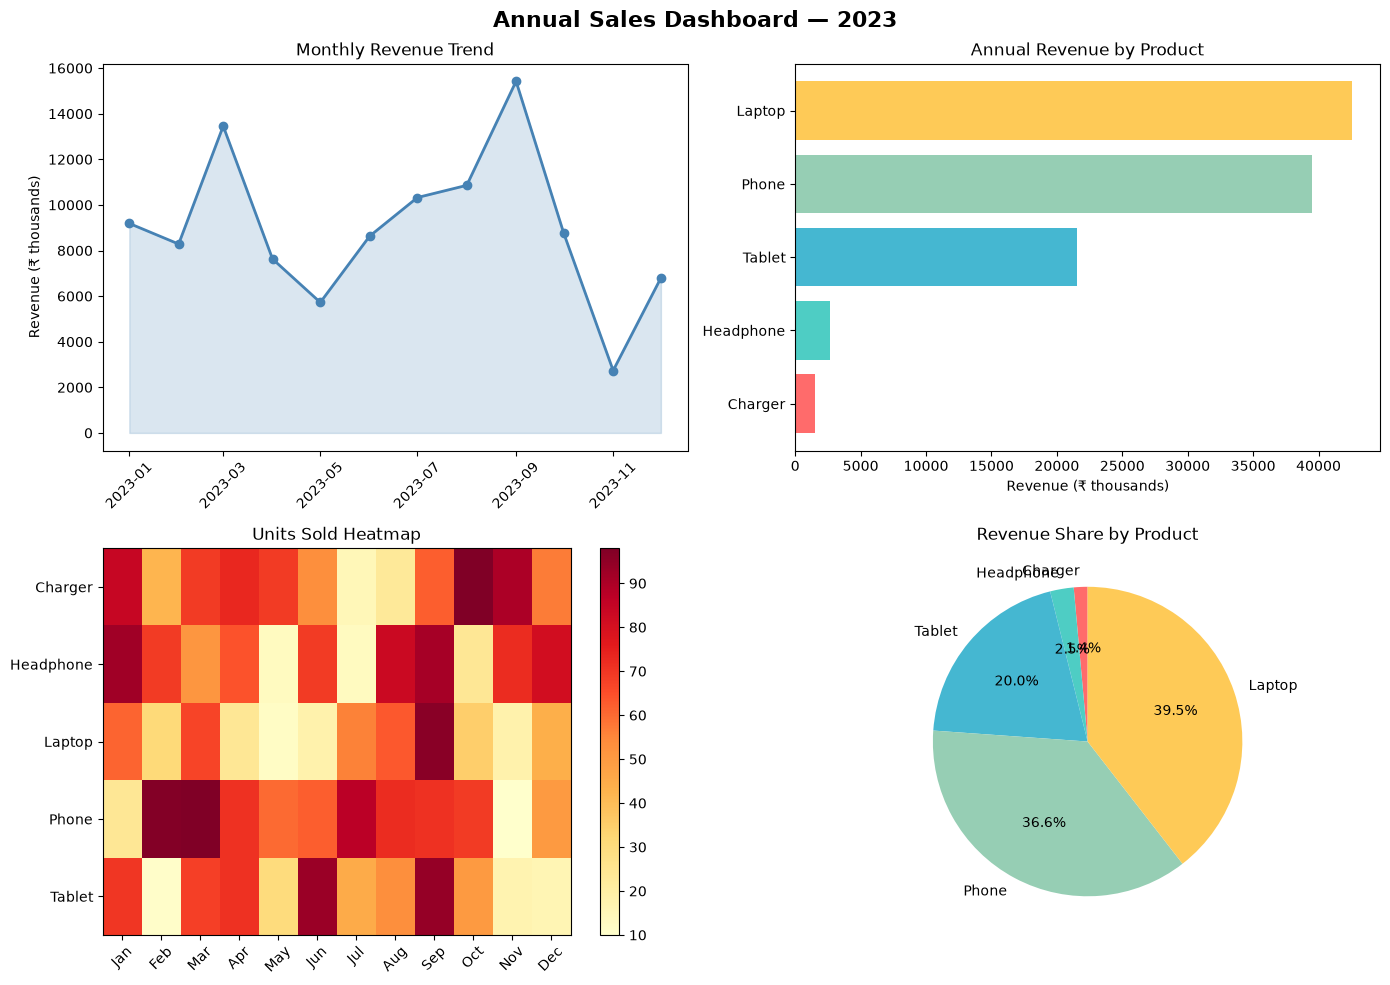

In [15]:
# Full analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Monthly revenue trend
monthly = sales_df.groupby('Date')['Revenue'].sum()
axes[0,0].plot(monthly.index, monthly.values/1000, marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(monthly.index, monthly.values/1000, alpha=0.2, color='steelblue')
axes[0,0].set_title("Monthly Revenue Trend")
axes[0,0].set_ylabel("Revenue (₹ thousands)")
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Revenue by product
product_rev = sales_df.groupby('Product')['Revenue'].sum().sort_values(ascending=True)
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FECA57']
axes[0,1].barh(product_rev.index, product_rev.values/1000, color=colors)
axes[0,1].set_title("Annual Revenue by Product")
axes[0,1].set_xlabel("Revenue (₹ thousands)")

# 3. Units sold heatmap
pivot_units = sales_df.pivot_table(values='Units', index='Product', columns='Month', aggfunc='sum')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot_units = pivot_units[month_order]
im = axes[1,0].imshow(pivot_units.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_xticks(range(12)); axes[1,0].set_xticklabels(month_order, rotation=45)
axes[1,0].set_yticks(range(5));  axes[1,0].set_yticklabels(pivot_units.index)
axes[1,0].set_title("Units Sold Heatmap")
plt.colorbar(im, ax=axes[1,0])

# 4. Top product share (pie)
wedges, texts, autotexts = axes[1,1].pie(
    product_rev.values, labels=product_rev.index,
    autopct='%1.1f%%', colors=colors, startangle=90)
axes[1,1].set_title("Revenue Share by Product")

plt.suptitle("Annual Sales Dashboard — 2023", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/sales_dashboard.png", dpi=100)
plt.show()

## Summary

| Task | Pandas Method |
|---|---|
| Load data | `pd.read_csv()`, `pd.read_excel()` |
| Explore | `.head()`, `.info()`, `.describe()` |
| Filter | `df[condition]`, `.loc`, `.iloc` |
| Missing data | `.isnull()`, `.fillna()`, `.dropna()` |
| Aggregate | `.groupby()`, `.agg()`, `.pivot_table()` |
| Combine | `pd.merge()`, `pd.concat()` |

**Next notebook →** `04_Data_Visualization_Matplotlib_Seaborn.ipynb`